In [2]:
# netPCF import
import spacenet as sn

# other imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.dpi'] = 200

netPCF_kwargs = dict(spatial_kernel_bandwidth=20,
                        spatial_kernel_n=2,
                        r_min=0, 
                        r_max=300,
                        r_step=10, 
                        edge_weight_name='Distance', 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1)   


In [4]:
which_embryo_1 = 'EMA36'
which_embryo_3 = 'EMA118'
path_to_data = '../data/murine_embryo_data_murphy_2022/'
file_path_1=path_to_data+which_embryo_1+'.csv'
file_path_3=path_to_data+which_embryo_3+'.csv'

embryo_surface_data_1 = pd.read_csv(file_path_1)
embryo_surface_data_3 = pd.read_csv(file_path_3)

points_1 = embryo_surface_data_1[['X','Y','Z']].to_numpy()
points_3 = embryo_surface_data_3[['X','Y','Z']].to_numpy()

G1=sn.utils.spatial_network_from_points(points_1,network_type='Delaunay',min_edge_distance=0,max_edge_distance=13)
G3=sn.utils.spatial_network_from_points(points_3,network_type='Delaunay',min_edge_distance=0,max_edge_distance=15)

#Min-Max Scaling
scaler = MinMaxScaler()

columns_to_scale = ['Wnt1', 'Wnt2', 'Wnt2B', 'Wnt3', 'Wnt3A', 'Wnt4',
                    'Wnt5A', 'Wnt6', 'Wnt7A', 'Wnt7B', 'Wnt10B', 
                    'Wnt11', 'Wnt16', 'Fzd1', 'Fzd3', 'Fzd4', 
                    'Fzd5', 'Fzd6', 'Fzd8', 'Fzd9', 'Fzd10']

embryo_surface_data_1[columns_to_scale] = scaler.fit_transform(embryo_surface_data_1[columns_to_scale])
embryo_surface_data_3[columns_to_scale] = scaler.fit_transform(embryo_surface_data_3[columns_to_scale])

# ostu's thresholding
lb_wnt6 = 0.60
lb_wnt1 = 0.55
lb_wnt2 = 0.55

# check for null

In [5]:
r_null_1,g_null_1,CI_null_1=sn.point_patterns.cross_pair_correlation_function(G1,**netPCF_kwargs)

Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 10004/10004 [02:52<00:00, 57.96contributions/s]


Computing confidence intervals via spatial bootstrap...


In [6]:
r_null_3,g_null_3,CI_null_3=sn.point_patterns.cross_pair_correlation_function(G3,**netPCF_kwargs)

Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 10008/10008 [02:00<00:00, 83.07contributions/s]


Computing confidence intervals via spatial bootstrap...


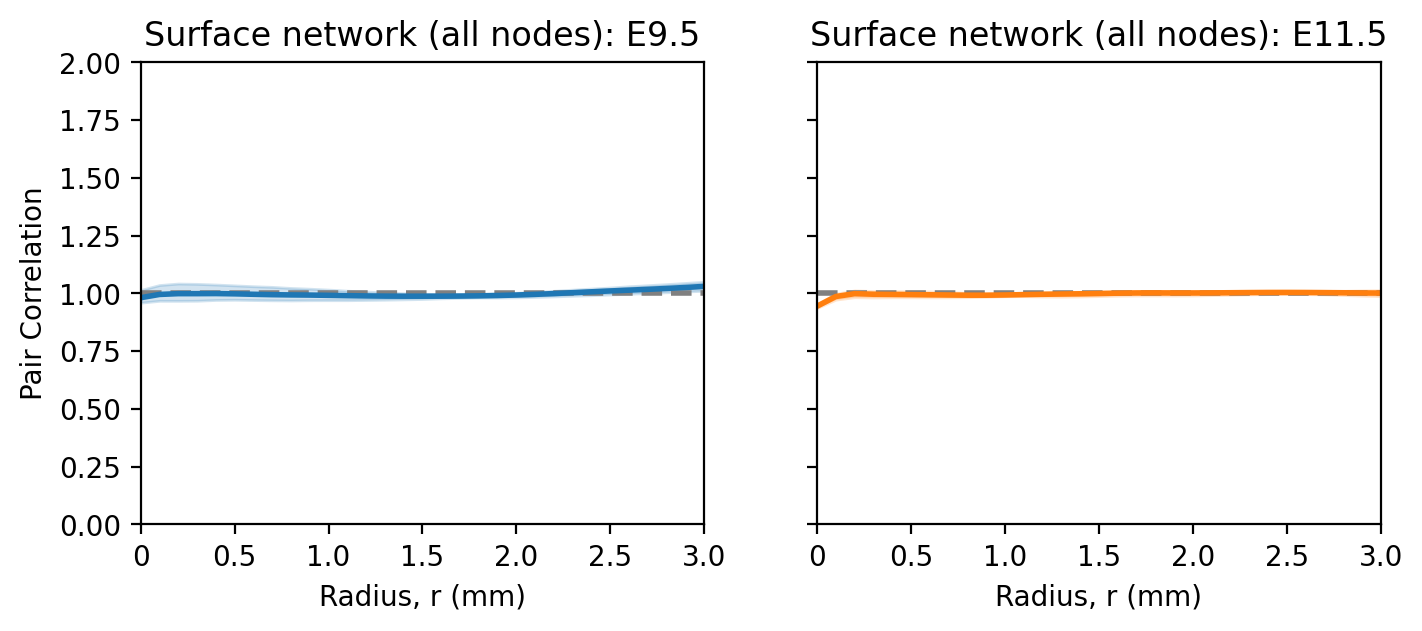

In [58]:
plt.close('all')

%matplotlib inline

fig, ax = plt.subplots(1,2,figsize=(8,3),sharey=True)
ax[0].axhline(y=1, color='grey', linestyle='--', linewidth=2)
ax[0].plot(r_null_1,g_null_1,label='E9.5',linewidth=2,color='tab:blue')
ax[0].fill_between(r_null_1, CI_null_1[0], CI_null_1[1], color='tab:blue', alpha=0.2)

ax[0].set_xticks([0,50,100,150,200,250,300])
ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5,3.0])

ax[0].set_xlim([0,300])
ax[0].set_ylim([0,2])
ax[0].set_xlabel('Radius, r (mm)')
ax[0].set_ylabel('Pair Correlation')
ax[0].set_title('Surface network (all nodes): E9.5')

ax[1].axhline(y=1, color='grey', linestyle='--', linewidth=2)
ax[1].plot(r_null_3,g_null_3,label='E11.5',linewidth=2,color='tab:orange')
ax[1].fill_between(r_null_3, CI_null_3[0], CI_null_3[1], color='tab:orange', alpha=0.2)

ax[1].set_xlim([0,300])
ax[1].set_xticks([0,50,100,150,200,250,300])
ax[1].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5,3.0])
ax[1].set_ylim([0,2])
ax[1].set_xlabel('Radius, r (mm)')
ax[1].set_title('Surface network (all nodes): E11.5')
#fig.savefig('figures/surface_network_all_nodes.png',dpi=300,bbox_inches='tight')

# correlation from wnt1

In [7]:
node_list_1_wnt1=np.array(list(G1.nodes()))[embryo_surface_data_1['Wnt1']>lb_wnt1]
node_list_3_wnt1=np.array(list(G3.nodes()))[embryo_surface_data_3['Wnt1']>lb_wnt1]

all_cols = ['Wnt1', 'Wnt2', 'Wnt6']
all_bounds = [lb_wnt1, lb_wnt2, lb_wnt6]
node_list_1_all = [np.array(list(G1.nodes()))[embryo_surface_data_1[col]>all_bounds[i]] for i,col in enumerate(all_cols)]
node_list_3_all = [np.array(list(G3.nodes()))[embryo_surface_data_3[col]>all_bounds[i]] for i,col in enumerate(all_cols)]

all_cols_names = ['Wnt1+', 'Wnt2+', 'Wnt6+']
netPCF_kwargs_fast = netPCF_kwargs | dict(return_confidence_interval=True)

results_dict = {}
for i in range(len(all_cols)):
    r_1,g_1,CI_1=sn.point_patterns.cross_pair_correlation_function(G1, 
                                                    node_list_1_wnt1, 
                                                    node_list_1_all[i], 
                                                    **netPCF_kwargs_fast)
    
    r_3,g_3,CI_3=sn.point_patterns.cross_pair_correlation_function(G3, 
                                                    node_list_3_wnt1, 
                                                    node_list_3_all[i], 
                                                    **netPCF_kwargs_fast)
    
    results_dict[all_cols_names[i]] ={}
    
    results_dict[all_cols_names[i]]['E9.5'] = {'r':r_1,'g':g_1,'CI':CI_1}
    results_dict[all_cols_names[i]]['E11.5'] = {'r':r_3,'g':g_3,'CI':CI_3}
    

Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 524/524 [00:18<00:00, 28.50contributions/s]


Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1135/1135 [00:22<00:00, 51.57contributions/s]


Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


...

Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 524/524 [00:18<00:00, 28.33contributions/s]


Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1135/1135 [00:19<00:00, 57.60contributions/s]

Computing confidence intervals via spatial bootstrap...


In [9]:
colors_1 = plt.get_cmap('Greens')
colors_array_1 = colors_1(np.linspace(0, 1, 10))  # Example of indexing to get 10 colors

colors_2 = plt.get_cmap('Reds')
colors_array_2 = colors_2(np.linspace(0, 1, 10))  # Example of indexing to get 10 colors

colors_3 = plt.get_cmap('Purples')
colors_array_3 = colors_3(np.linspace(0, 1, 10))  # Example of indexing to get 10 colors

these_colors_titles = [colors_array_1[-2],colors_array_2[-2],colors_array_3[-2]]

Text(0, 0.5, 'Pair Correlation')

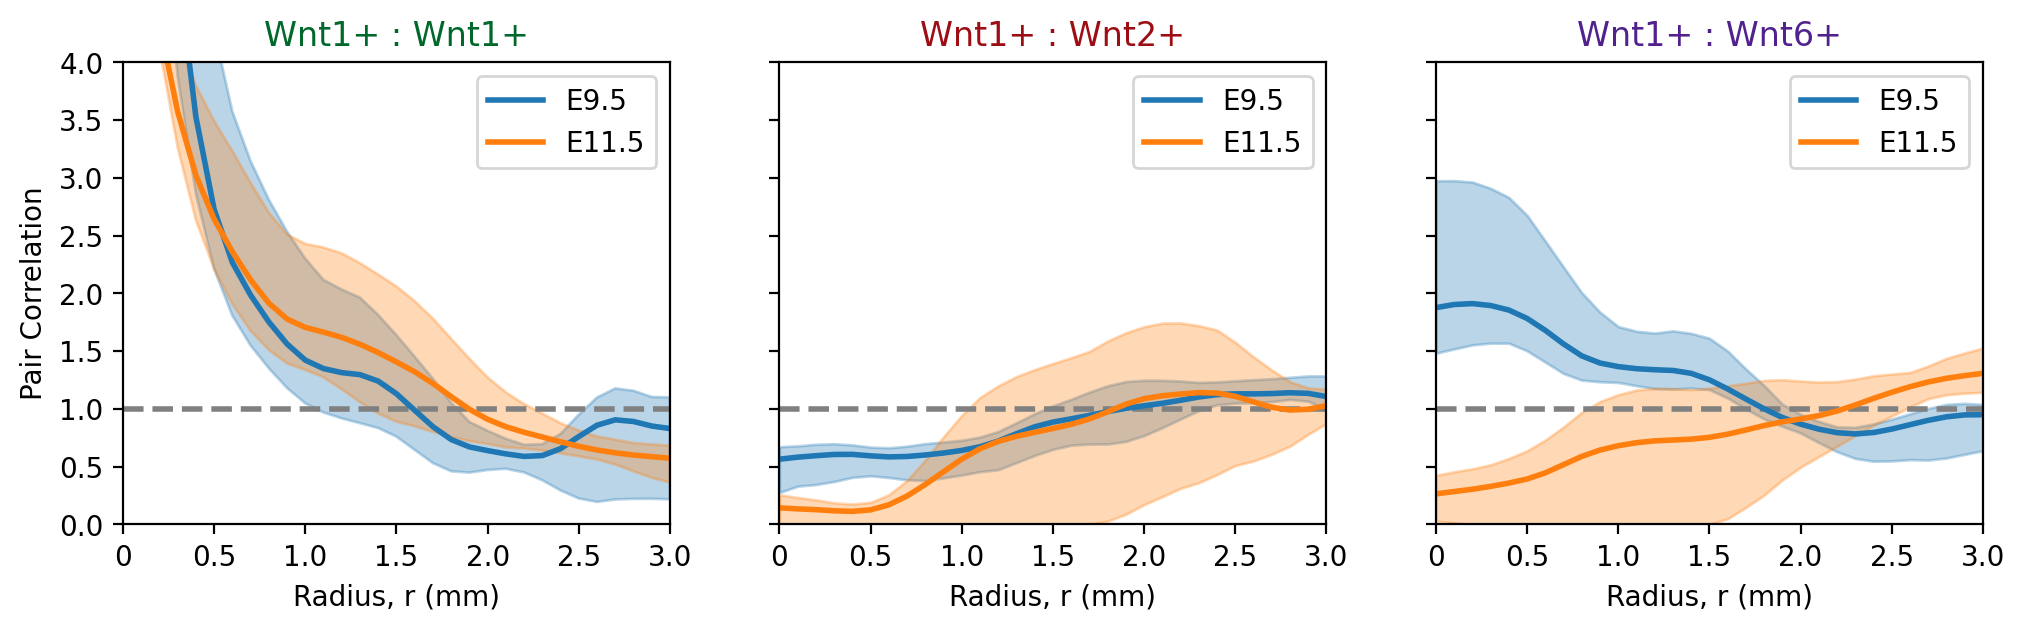

In [10]:

%matplotlib inline
fig, ax = plt.subplots(1,len(all_cols),figsize=(4*len(all_cols),3),sharey=True)

for i in range(len(all_cols)):
    this_result_1 = results_dict[all_cols_names[i]]['E9.5']
    this_result_2 = results_dict[all_cols_names[i]]['E11.5']
    
    r_1 = this_result_1['r']
    g_1 = this_result_1['g']
    CI_1 = this_result_1['CI']
    
    r_3 = this_result_2['r']
    g_3 = this_result_2['g']
    CI_3 = this_result_2['CI']

    ax[i].axhline(y=1, color='grey', linestyle='--', linewidth=2)
    ax[i].plot(r_1,g_1,linewidth=2,label='E9.5',color='tab:blue')   
    ax[i].fill_between(r_1, CI_1[0], CI_1[1],color='tab:blue',alpha=0.3)
    ax[i].plot(r_3,g_3,linewidth=2,label='E11.5',color='tab:orange')   
    ax[i].fill_between(r_3, CI_3[0], CI_3[1],color='tab:orange',alpha=0.3)
    ax[i].set_xlabel('Radius, r (mm)')
    ax[i].set_xticks([0,50,100,150,200,250,300])
    ax[i].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5,3.0])
    #ax[i].set_ylabel('netXPCF, $g^{net}(r)$')
    ax[i].set_title(f'Wnt1+ : {all_cols_names[i]}',color=these_colors_titles[i])
    ax[i].set_ylim([0,4]) 
    ax[i].set_xlim([0,netPCF_kwargs_fast['r_max']]) 
    ax[i].legend()

ax[0].set_ylabel('Pair Correlation')
#fig.savefig('figures/xpcfs_wnt1_scaled.png',dpi=200,bbox_inches='tight')



### Weighted PCFs from wnt1+ to wnt6 expression

In [11]:
wpcf_kwargs = netPCF_kwargs | dict(marker_kernel_bandwidth=0.1,marker_kernel_n=2,marker_min=0, marker_max=1, marker_step=0.05,return_confidence_interval=False)

e9_wnt1_pos = np.array(list(G1.nodes()))[embryo_surface_data_1['Wnt1']>lb_wnt1]
e11_wnt1_pos = np.array(list(G3.nodes()))[embryo_surface_data_3['Wnt1']>lb_wnt1]

e9_wnt6_exist = np.array(list(G1.nodes()))[embryo_surface_data_1['Wnt6']>0]
e9_wnt6_labels = np.array(embryo_surface_data_1['Wnt6'][embryo_surface_data_1['Wnt6']>0])

e11_wnt6_exist = np.array(list(G3.nodes()))[embryo_surface_data_3['Wnt6']>0]
e11_wnt6_labels = np.array(embryo_surface_data_3['Wnt6'][embryo_surface_data_3['Wnt6']>0])


In [12]:
tau_e9,r_e9, g_e9 = sn.point_patterns.weighted_pair_correlation_function(G1,
                                                   e9_wnt6_labels, 
                                                   nodes_a=e9_wnt1_pos,
                                                   nodes_b=e9_wnt6_exist, 
                                                    **wpcf_kwargs)

Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 524/524 [00:19<00:00, 26.86contributions/s]


In [13]:
tau_e11, r_e11, g_e11 = sn.point_patterns.weighted_pair_correlation_function(G3,
                                                   e11_wnt6_labels, 
                                                   nodes_a=e11_wnt1_pos,
                                                   nodes_b=e11_wnt6_exist, 
                                                    **wpcf_kwargs)

Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1135/1135 [00:20<00:00, 55.47contributions/s]


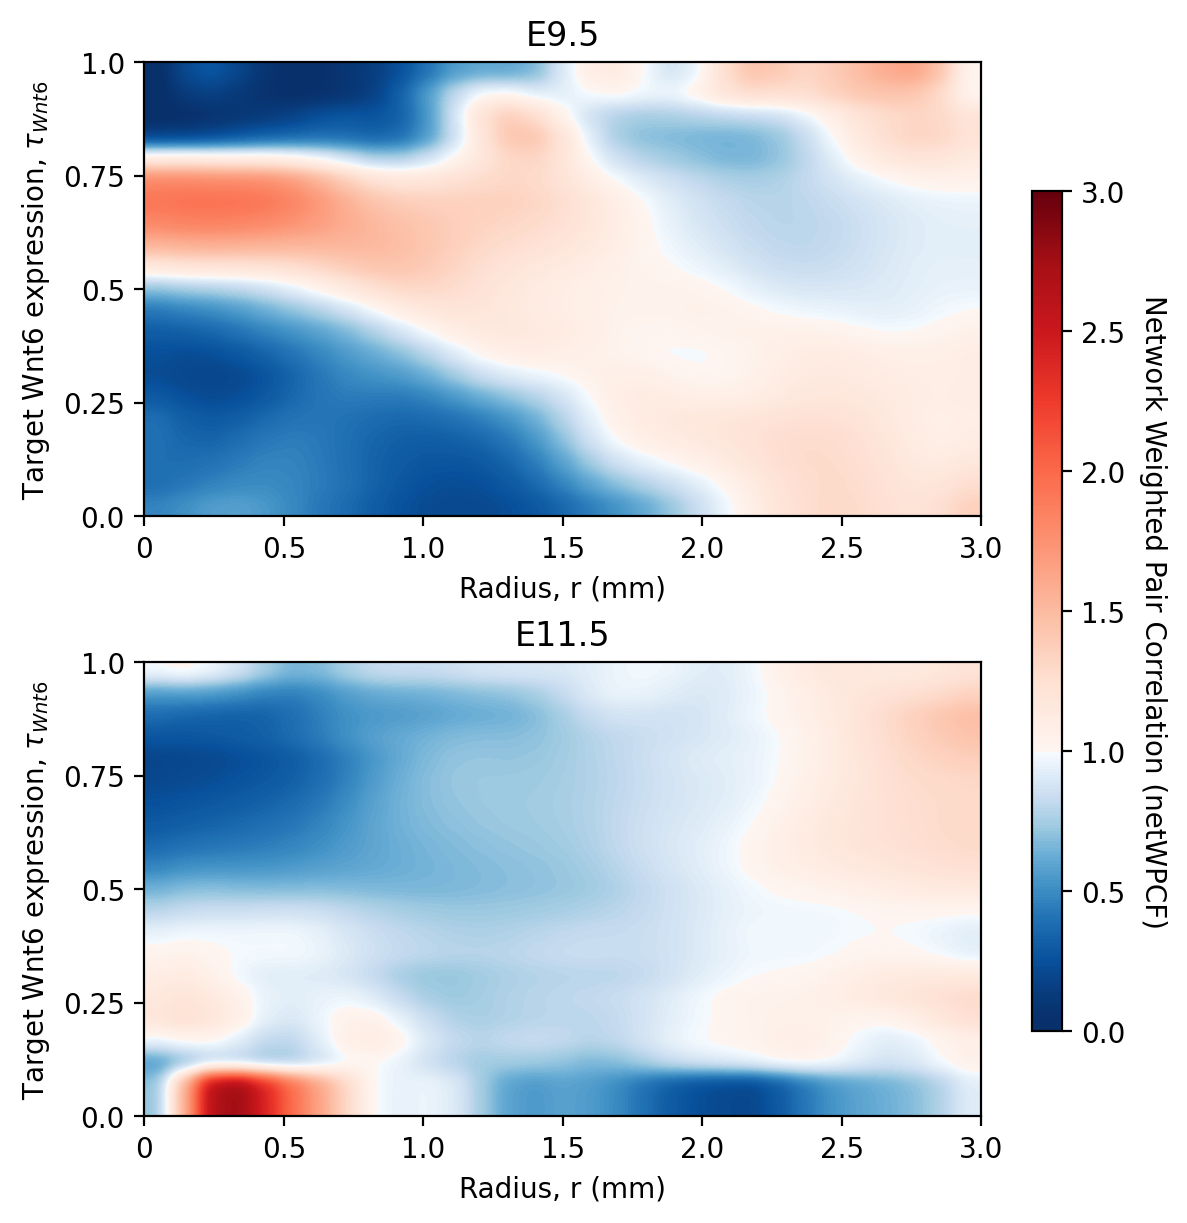

In [14]:

import matplotlib.colors as mcolors
axis_kwargs = dict(ylabel='Target Wnt6 expression, $\\tau_{Wnt6}$',zlabel='Target mark A, $\\tau_{B}$',xlabel='Radius, r (mm)',number_of_ticks=int(5))

colorbar_limit=3
nonlin_cbar_scalefactor=1.5
vmin = 0
vmax = colorbar_limit
ncolors=1000
colorbar_limit=3

nonlin_num=int(np.round(ncolors*(1/colorbar_limit)))

colors2 = plt.cm.Reds(np.linspace(0, 1, int(ncolors-nonlin_num)))
colors1 = plt.cm.Blues_r((np.linspace(0, 1 , nonlin_num)**nonlin_cbar_scalefactor))

colors = np.vstack((colors1, colors2))
cmap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

fig, ax = plt.subplots(2,1,figsize=(5,6),layout='constrained')  
heatmap=ax[0].imshow(g_e9,origin='lower',extent=[np.min(r_e9),np.max(r_e9),np.min(tau_e9),np.max(tau_e9)],cmap=cmap,vmin=vmin,vmax=vmax,interpolation='gaussian',aspect='auto')
heatmap=ax[1].imshow(g_e11,origin='lower',extent=[np.min(r_e11),np.max(r_e11),np.min(tau_e11),np.max(tau_e11)],cmap=cmap,vmin=vmin,vmax=vmax,interpolation='gaussian',aspect='auto')

these_ticks_y = np.linspace(0,1,axis_kwargs['number_of_ticks'])
these_ticks_x = np.linspace(0,wpcf_kwargs['r_max'],axis_kwargs['number_of_ticks'])

these_ticks_labels_x = np.round(np.linspace(0,wpcf_kwargs['r_max'],axis_kwargs['number_of_ticks']),2)
these_ticks_labels_y = np.round(np.linspace(0,1,axis_kwargs['number_of_ticks']),2)

ax[0].set_yticks(these_ticks_y)

ax[0].set_xticks([0,50,100,150,200,250,300])
ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5,3.0])
ax[0].set_yticklabels(these_ticks_labels_y)
ax[0].set_ylabel(axis_kwargs['ylabel'])
ax[0].set_xlabel(axis_kwargs['xlabel'])

ax[1].set_yticks(these_ticks_y)
ax[1].set_yticklabels(these_ticks_labels_y)
ax[1].set_xticks([0,50,100,150,200,250,300])
ax[1].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5,3.0])
ax[1].set_ylabel(axis_kwargs['ylabel'])
ax[1].set_xlabel(axis_kwargs['xlabel'])

ax[0].set_title('E9.5') 
ax[1].set_title('E11.5')

cbar_ax = fig.add_axes([1.02, 0.15, 0.03, 0.7])  # Position for colorbar
cbar = fig.colorbar(heatmap, cax=cbar_ax)
cbar.set_label('Network Weighted Pair Correlation (netWPCF)', rotation=270, labelpad=15)
#fig.savefig('figures/wpcf_wnt1_wnt6.png',dpi=300,bbox_inches='tight')


### visualisation of networks

Text(0.5, 1.1, 'Wnt1+')

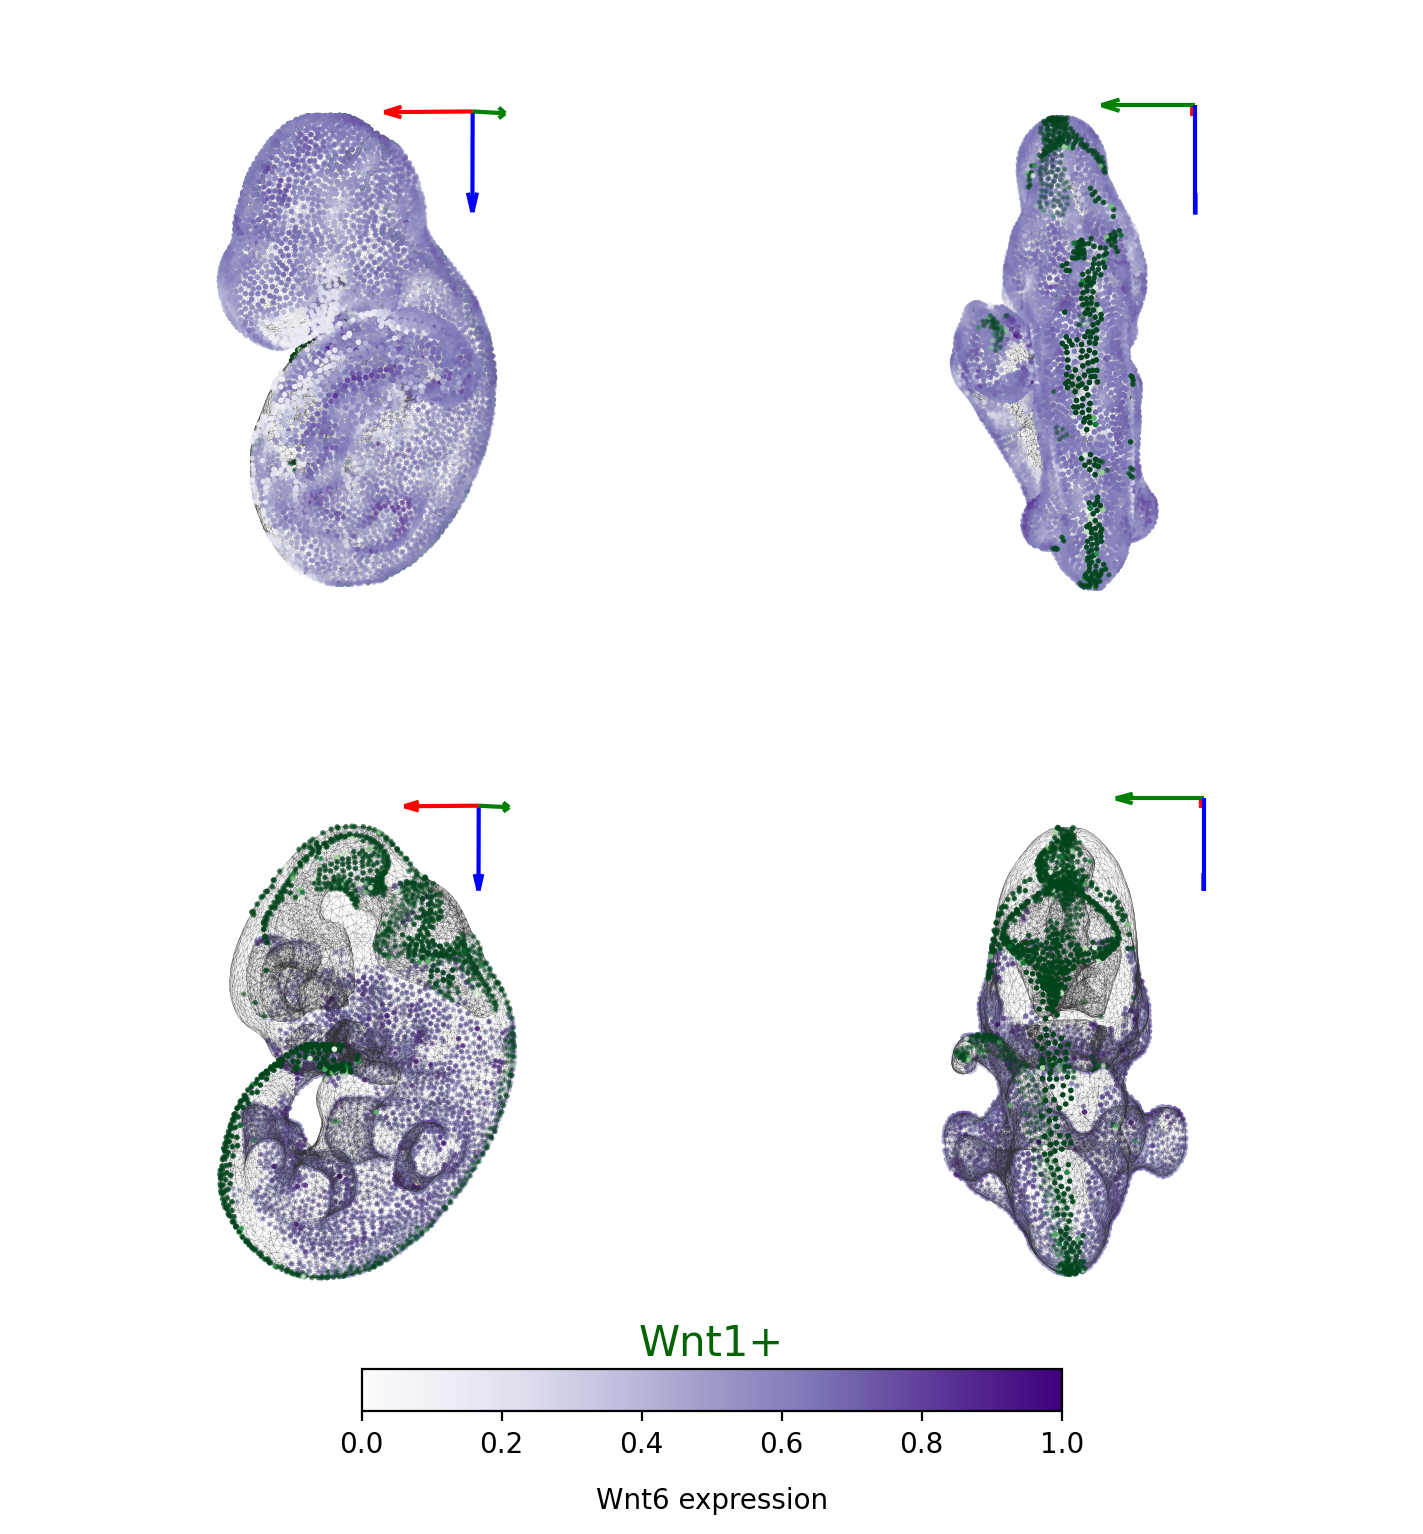

In [15]:
from mpl_toolkits.mplot3d import Axes3D


plt.close('all')
%matplotlib inline

this_gene = 'Wnt1'
this_gene_other = 'Wnt6'    

fig, ax = plt.subplots(2, 2, figsize=(7, 7), subplot_kw={'projection': '3d'}, layout='constrained')


sn.utils.plot_spatial_network(G1,ax=ax[0,0],edge_width=0.05,marker_size=0)

this_scat = ax[0,0].scatter(points_1[embryo_surface_data_1[this_gene_other]>0.1, 0],
                            points_1[embryo_surface_data_1[this_gene_other]>0.1, 1],
                            points_1[embryo_surface_data_1[this_gene_other]>0.1, 2],
                            c=embryo_surface_data_1[this_gene_other][embryo_surface_data_1[this_gene_other]>0.1],
                            s=1,zorder=100,cmap='Purples',vmin=0,vmax=1)


this_scat = ax[0,0].scatter(points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 0],
                              points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 1],
                              points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 2],
                              c=embryo_surface_data_1[this_gene][embryo_surface_data_1[this_gene]>lb_wnt1],
                              s=1,zorder=200,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[0,0].set_aspect('equal')
ax[0,0].set_zlim(ax[0,0].get_zlim()[::-1])  # Reverse the z-axis limits
ax[0,0].view_init(elev=5, azim=70,roll=0)  # Set the elevation and azimuthal angle for side view
ax[0,0].set_axis_off()

arrow_length = 100
ax[0, 0].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 0].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 0].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)

sn.utils.plot_spatial_network(G1,ax=ax[0,1],edge_width=0.05,marker_size=0)

this_scat = ax[0,1].scatter(points_1[embryo_surface_data_1[this_gene_other]>0.1, 0],
                            points_1[embryo_surface_data_1[this_gene_other]>0.1, 1],
                            points_1[embryo_surface_data_1[this_gene_other]>0.1, 2],
                            c=embryo_surface_data_1[this_gene_other][embryo_surface_data_1[this_gene_other]>0.1],
                            s=1,zorder=100,cmap='Purples',vmin=0,vmax=1)


this_scat = ax[0,1].scatter(points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 0],
                              points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 1],
                              points_1[embryo_surface_data_1[this_gene]>lb_wnt1, 2],
                              c=embryo_surface_data_1[this_gene][embryo_surface_data_1[this_gene]>lb_wnt1],
                              s=1,zorder=200,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[0,1].set_aspect('equal')
ax[0,1].set_zlim(ax[0,1].get_zlim()[::-1])  # Reverse the z-axis limits
ax[0,1].view_init(elev=0, azim=-180,roll=0)  # Set the elevation and azimuthal angle for side view
ax[0,1].set_axis_off()


arrow_length = 100
ax[0, 1].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 1].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 1].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)



sn.utils.plot_spatial_network(G3,ax=ax[1,0],edge_width=0.05,marker_size=0)


this_scat = ax[1,0].scatter(points_3[embryo_surface_data_3[this_gene_other]>0.1, 0],
                              points_3[embryo_surface_data_3[this_gene_other]>0.1, 1],
                              points_3[embryo_surface_data_3[this_gene_other]>0.1, 2],
                              c=embryo_surface_data_3[this_gene_other][embryo_surface_data_3[this_gene_other]>0.1],
                              s=1,zorder=200,cmap='Purples',vmin=0,vmax=1)

this_scat = ax[1,0].scatter(points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 0],
                              points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 1],
                              points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 2],
                              c=embryo_surface_data_3[this_gene][embryo_surface_data_3[this_gene]>lb_wnt1],
                              s=1,zorder=100,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[1,0].set_aspect('equal')
ax[1,0].set_zlim(ax[1,0].get_zlim()[::-1])  # Reverse the z-axis limits
ax[1,0].view_init(elev=5, azim=70,roll=0)  # Set the elevation and azimuthal angle for side view
ax[1,0].set_axis_off()

arrow_length = 100
ax[1, 0].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail')
ax[1, 0].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail')
ax[1, 0].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail')



sn.utils.plot_spatial_network(G3,ax=ax[1,1],edge_width=0.05,marker_size=0)


this_scat_for_plot = ax[1,1].scatter(points_3[embryo_surface_data_3[this_gene_other]>0.1, 0],
                              points_3[embryo_surface_data_3[this_gene_other]>0.1, 1],
                              points_3[embryo_surface_data_3[this_gene_other]>0.1, 2],
                              c=embryo_surface_data_3[this_gene_other][embryo_surface_data_3[this_gene_other]>0.1],
                              s=1,zorder=200,cmap='Purples',vmin=0,vmax=1)

this_scat = ax[1,1].scatter(points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 0],
                              points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 1],
                              points_3[embryo_surface_data_3[this_gene]>lb_wnt1, 2],
                              c=embryo_surface_data_3[this_gene][embryo_surface_data_3[this_gene]>lb_wnt1],
                              s=1,zorder=100,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[1,1].set_aspect('equal')
ax[1,1].set_zlim(ax[1,1].get_zlim()[::-1])  # Reverse the z-axis limits
ax[1,1].view_init(elev=0, azim=-180,roll=0)  # Set the elevation and azimuthal angle for side view
ax[1,1].set_axis_off()

arrow_length = 100
ax[1, 1].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 1].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 1].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)




cbar_ax_for_plot = fig.add_axes([0.25, 0, 0.5, 0.03])  # Position for colorbar
cbar_for_plot = fig.colorbar(this_scat_for_plot, cax=cbar_ax_for_plot, orientation='horizontal')
cbar_for_plot.set_label(this_gene_other + ' expression', rotation=0, labelpad=10)

cbar_ax_for_plot.text(0.5, 1.1, this_gene+'+', ha='center', va='bottom', fontsize=15, color='darkgreen', transform=cbar_ax_for_plot.transAxes)
#fig.savefig('figures/spatial_network_wnt1_wnt6.png',dpi=300,bbox_inches='tight')



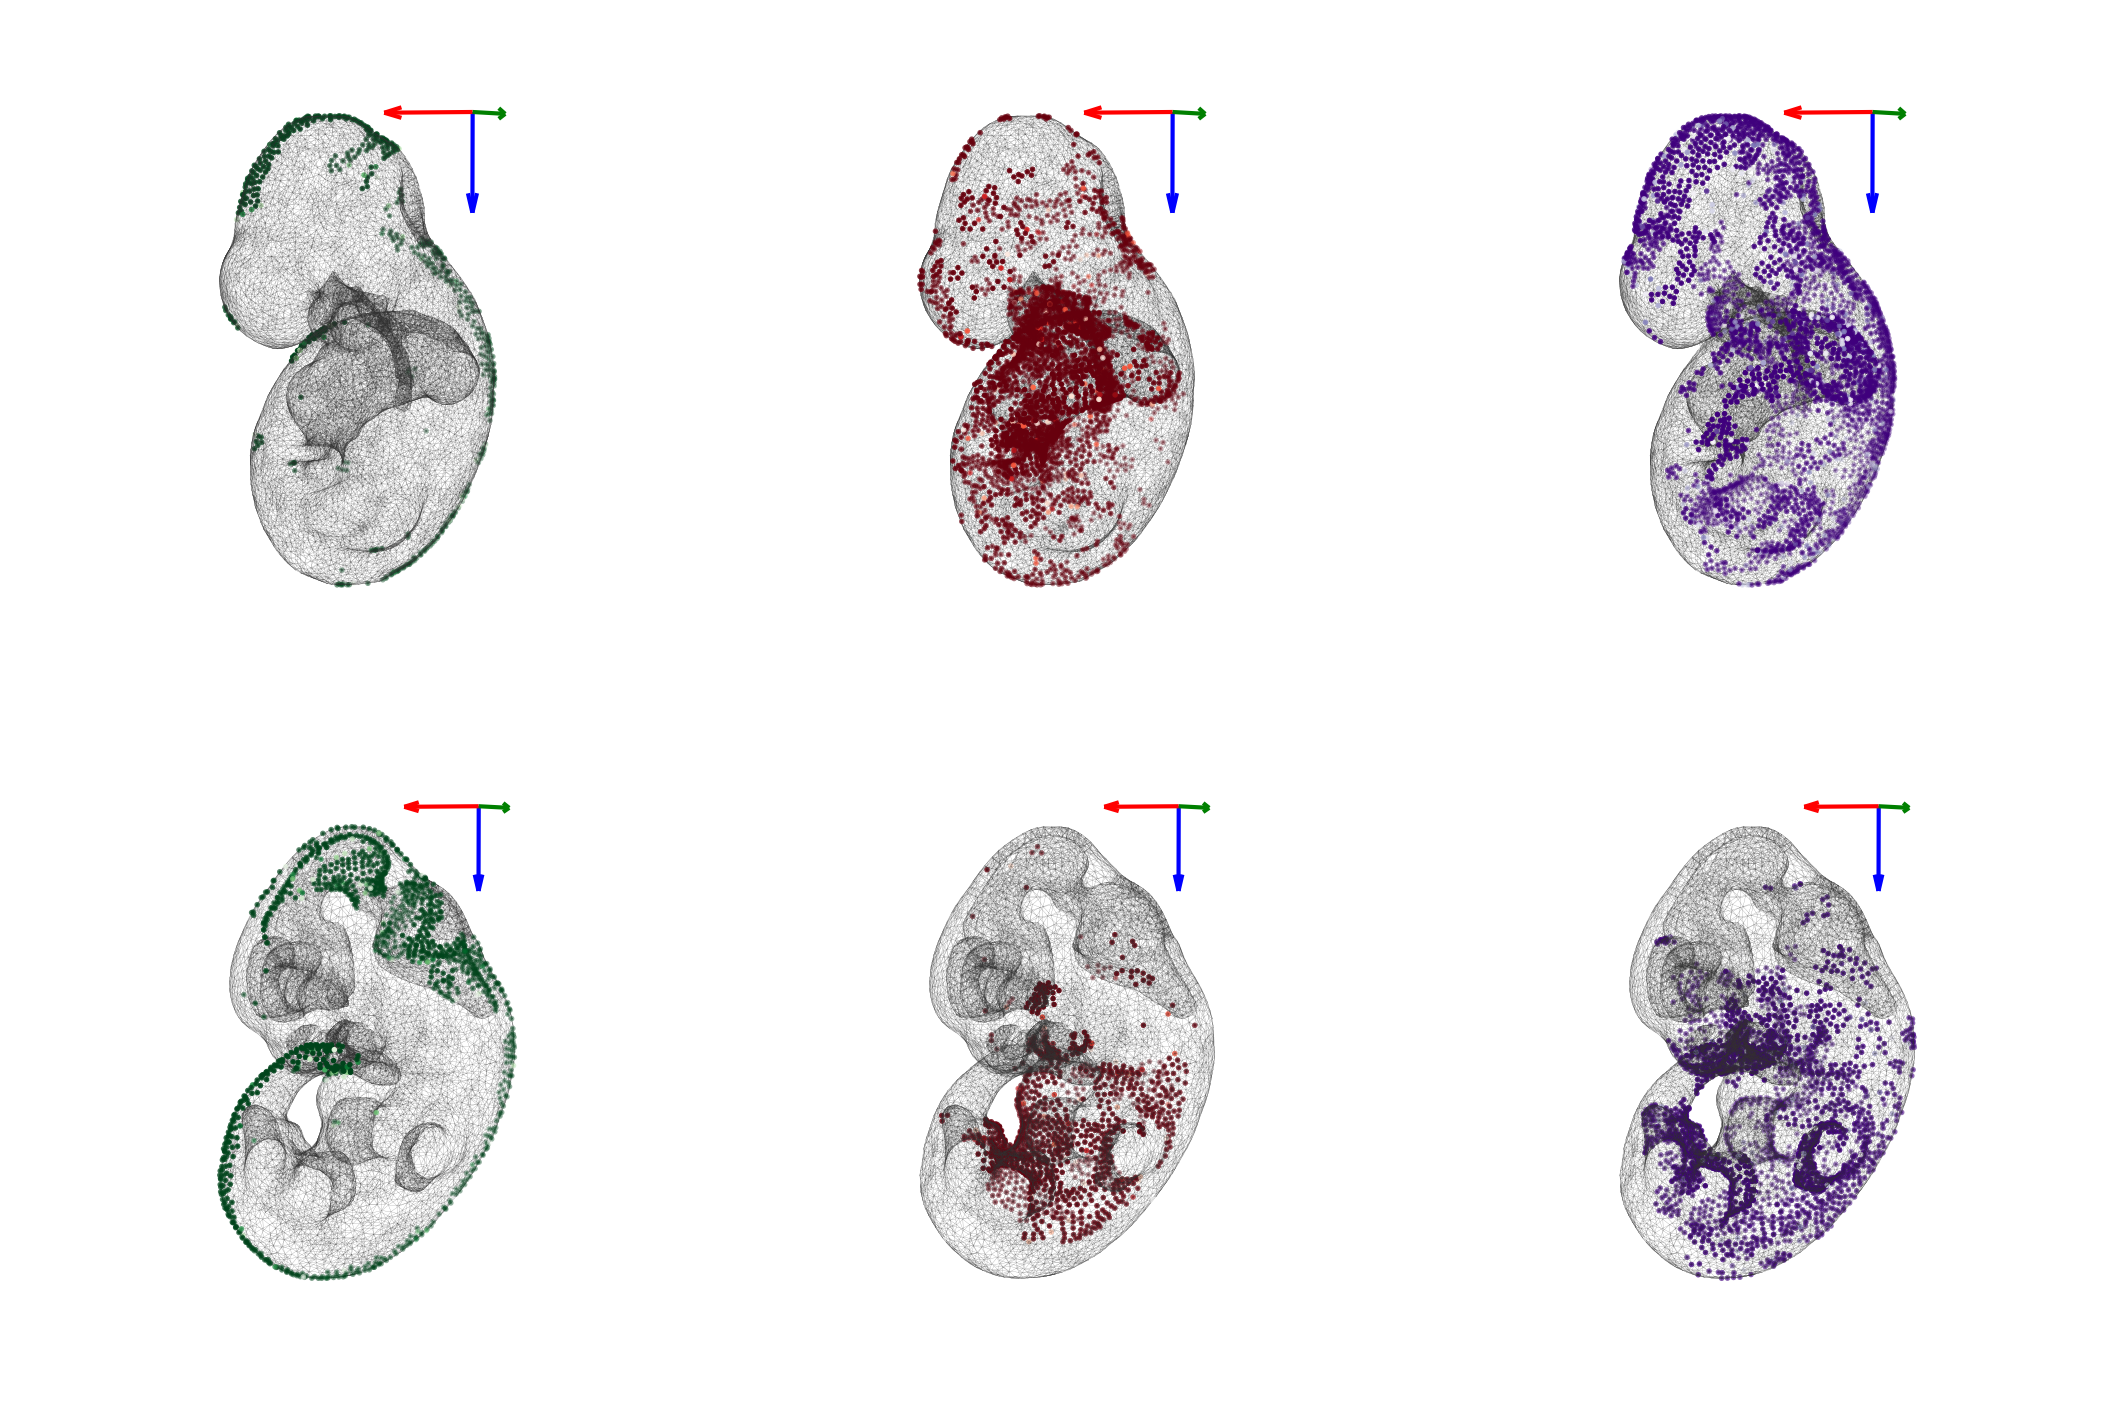

In [16]:

this_elev = 5
this_azim = 70
marker_size = 1
edge_width = 0.05

%matplotlib inline
  
fig, ax = plt.subplots(2, 3, figsize=(10.5, 7), subplot_kw={'projection': '3d'}, layout='constrained')

sn.utils.plot_spatial_network(G1,ax=ax[0,0],edge_width=edge_width,marker_size=0)



this_scat = ax[0,0].scatter(points_1[embryo_surface_data_1['Wnt1']>lb_wnt1, 0],
                              points_1[embryo_surface_data_1['Wnt1']>lb_wnt1, 1],
                              points_1[embryo_surface_data_1['Wnt1']>lb_wnt1, 2],
                              c=embryo_surface_data_1['Wnt1'][embryo_surface_data_1['Wnt1']>lb_wnt1],
                              s=marker_size,zorder=200,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[0,0].set_aspect('equal')
ax[0,0].set_zlim(ax[0,0].get_zlim()[::-1])  # Reverse the z-axis limits
ax[0,0].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view


ax[0,0].set_axis_off()

arrow_length = 100
ax[0, 0].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 0].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 0].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)

sn.utils.plot_spatial_network(G1,ax=ax[0,1],edge_width=edge_width,marker_size=0)
this_scat = ax[0,1].scatter(points_1[embryo_surface_data_1['Wnt2']>lb_wnt2, 0],
                              points_1[embryo_surface_data_1['Wnt2']>lb_wnt2, 1],
                              points_1[embryo_surface_data_1['Wnt2']>lb_wnt2, 2],
                              c=embryo_surface_data_1['Wnt2'][embryo_surface_data_1['Wnt2']>lb_wnt2],
                              s=marker_size,zorder=200,cmap='Reds',vmin=lb_wnt2,vmax=lb_wnt2+1e-2)

ax[0,1].set_aspect('equal')
ax[0,1].set_zlim(ax[0,1].get_zlim()[::-1])  # Reverse the z-axis limits
ax[0,1].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view

ax[0,1].set_axis_off()

arrow_length = 100
ax[0, 1].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 1].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 1].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)


sn.utils.plot_spatial_network(G1,ax=ax[0,2],edge_width=edge_width,marker_size=0)
this_scat = ax[0,2].scatter(points_1[embryo_surface_data_1['Wnt6']>lb_wnt6, 0],
                              points_1[embryo_surface_data_1['Wnt6']>lb_wnt6, 1],
                              points_1[embryo_surface_data_1['Wnt6']>lb_wnt6, 2],
                              c=embryo_surface_data_1['Wnt6'][embryo_surface_data_1['Wnt6']>lb_wnt6],
                              s=marker_size,zorder=200,cmap='Purples',vmin=lb_wnt6,vmax=lb_wnt6+1e-2)

ax[0,2].set_aspect('equal')
ax[0,2].set_zlim(ax[0,2].get_zlim()[::-1])  # Reverse the z-axis limits
ax[0,2].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view


ax[0,2].set_axis_off()

arrow_length = 100
ax[0, 2].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 2].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[0, 2].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)


####### E11.5 #######

sn.utils.plot_spatial_network(G3,ax=ax[1,0],edge_width=edge_width,marker_size=0)

this_scat = ax[1,0].scatter(points_3[embryo_surface_data_3['Wnt1']>lb_wnt1, 0],
                              points_3[embryo_surface_data_3['Wnt1']>lb_wnt1, 1],
                              points_3[embryo_surface_data_3['Wnt1']>lb_wnt1, 2],
                              c=embryo_surface_data_3['Wnt1'][embryo_surface_data_3['Wnt1']>lb_wnt1],
                              s=marker_size,zorder=200,cmap='Greens',vmin=lb_wnt1,vmax=lb_wnt1+1e-2)

ax[1,0].set_aspect('equal')
ax[1,0].set_zlim(ax[1,0].get_zlim()[::-1])  # Reverse the z-axis limits
ax[1,0].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view

ax[1,0].set_axis_off()

arrow_length = 100
ax[1, 0].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 0].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 0].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)


sn.utils.plot_spatial_network(G3,ax=ax[1,1],edge_width=edge_width,marker_size=0)
this_scat = ax[1,1].scatter(points_3[embryo_surface_data_3['Wnt2']>lb_wnt2, 0],
                              points_3[embryo_surface_data_3['Wnt2']>lb_wnt2, 1],
                              points_3[embryo_surface_data_3['Wnt2']>lb_wnt2, 2],
                              c=embryo_surface_data_3['Wnt2'][embryo_surface_data_3['Wnt2']>lb_wnt2],
                              s=marker_size,zorder=200,cmap='Reds',vmin=lb_wnt2,vmax=lb_wnt2+1e-2)

ax[1,1].set_aspect('equal')
ax[1,1].set_zlim(ax[1,1].get_zlim()[::-1])  # Reverse the z-axis limits
ax[1,1].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view

ax[1,1].set_axis_off()

arrow_length = 100
ax[1, 1].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 1].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 1].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)


sn.utils.plot_spatial_network(G3,ax=ax[1,2],edge_width=edge_width,marker_size=0)
this_scat = ax[1,2].scatter(points_3[embryo_surface_data_3['Wnt6']>lb_wnt6, 0],
                              points_3[embryo_surface_data_3['Wnt6']>lb_wnt6, 1],
                              points_3[embryo_surface_data_3['Wnt6']>lb_wnt6, 2],
                              c=embryo_surface_data_3['Wnt6'][embryo_surface_data_3['Wnt6']>lb_wnt6],
                              s=marker_size,zorder=200,cmap='Purples',vmin=lb_wnt6,vmax=lb_wnt6+1e-2)

ax[1,2].set_aspect('equal')
ax[1,2].set_zlim(ax[1,2].get_zlim()[::-1])  # Reverse the z-axis limits
ax[1,2].view_init(elev=this_elev, azim=this_azim,roll=0)  # Set the elevation and azimuthal angle for side view

ax[1,2].set_axis_off()

arrow_length = 100
ax[1, 2].quiver(0, 0, 0, arrow_length, 0, 0, color='r', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 2].quiver(0, 0, 0, 0, arrow_length, 0, color='g', arrow_length_ratio=0.2, pivot='tail',zorder=100000)
ax[1, 2].quiver(0, 0, 0, 0, 0, arrow_length, color='b', arrow_length_ratio=0.2, pivot='tail',zorder=100000)


#fig.savefig('figures/surface_network_threshold_wnt_w_arrows.png',dpi=300,bbox_inches='tight')